In [ ]:
!pip install casadi -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 10.6 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 8.9 MB/s eta 0:00:00


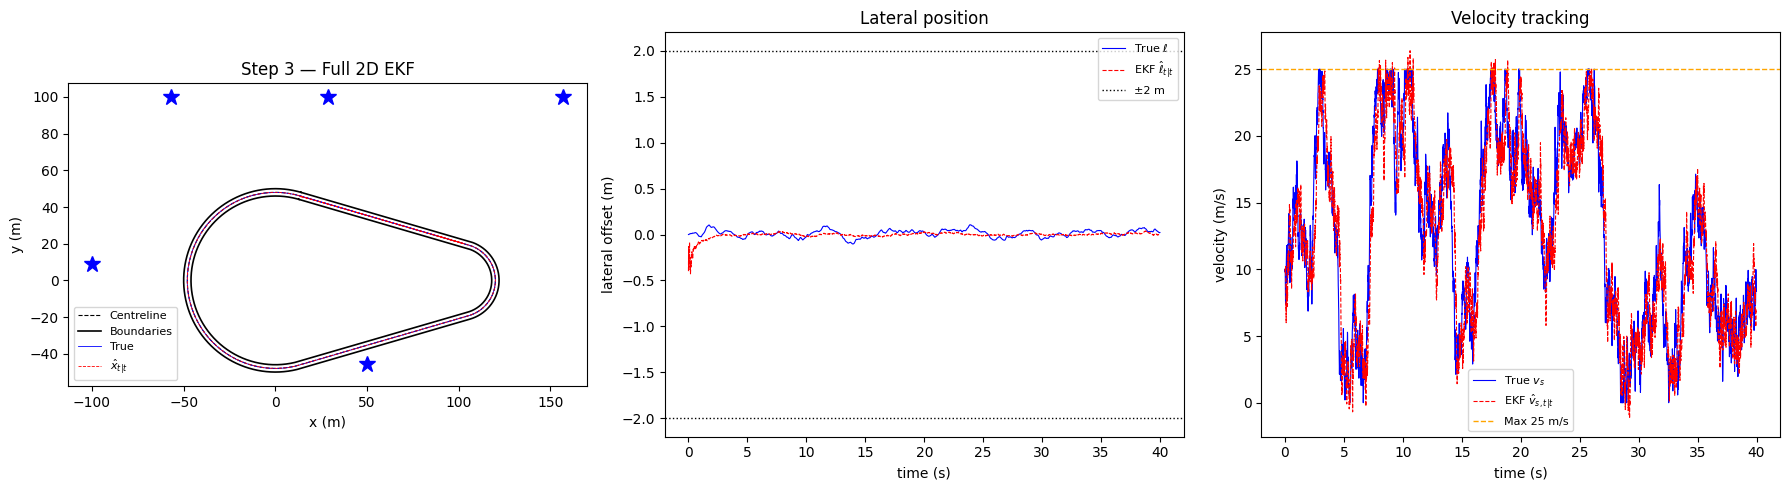

mean arc-length error : 0.250 m
mean lateral error    : 0.038 m
lateral bounds OK     : True
speed bounds OK       : True


In [1]:
!pip install casadi -q

import numpy as np
import matplotlib.pyplot as plt
import casadi.casadi as cs

np.random.seed(42)

# ── Track geometry — from modelling.ipynb (member A: ChenhuiCui) ──────────
R_A = 48.0
R_B = 20.0
d   = 100.0
w   = 2.0

alpha = np.arcsin((R_A - R_B) / d)
cos_a = np.cos(alpha)
sin_a = np.sin(alpha)
l_tan   = np.sqrt(d**2 - (R_A - R_B)**2)
l_arc_A = R_A * (np.pi + 2*alpha)
l_arc_B = R_B * (np.pi - 2*alpha)
L = 2*l_tan + l_arc_A + l_arc_B

A_centre = np.array([0.0, 0.0])
B_centre = np.array([d,   0.0])
s1 = l_tan
s2 = s1 + l_arc_B
s3 = s2 + l_tan

A_top = A_centre + R_A * np.array([sin_a,  cos_a])
B_bot = B_centre + R_B * np.array([sin_a, -cos_a])

def s_to_xy(s):
    s = s % L
    if s < s1:
        return A_top + s * np.array([cos_a, -sin_a])
    elif s < s2:
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return B_centre + R_B * np.array([np.cos(theta), np.sin(theta)])
    elif s < s3:
        return B_bot + (s - s2) * np.array([-cos_a, -sin_a])
    else:
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return A_centre + R_A * np.array([np.cos(theta), np.sin(theta)])

def s_to_normal(s):
    """Unit outward normal — ell>0: outer wall, ell<0: inner wall."""
    s = s % L
    if s < s1:
        return np.array([sin_a, cos_a])
    elif s < s2:
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return np.array([np.cos(theta), np.sin(theta)])
    elif s < s3:
        return np.array([sin_a, -cos_a])
    else:
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return np.array([np.cos(theta), np.sin(theta)])

def sl_to_xy(s, ell):
    return s_to_xy(s) + ell * s_to_normal(s)

# ── A2: Vehicle motion model — from modelling.ipynb (member A) ────────────
# State: z_t = [s, ell, vs, vl]
# Longitudinal: AR(1) centred at 10 m/s (phi_vs = 0.999)
# Lateral: spring-damper driver model
#   vl_{t+1} = phi_1 * vl_t - h*k2 * ell_t + w_ell
h      = 0.01
phi_vs = 0.999
phi_1  = 0.9
k2     = 10.0

A = np.array([
    [1,      0,    h,     0  ],
    [0,      1,    0,     h  ],
    [0,      0,  phi_vs,  0  ],
    [0, -h*k2,    0,   phi_1],
])
G = np.array([[0,0],[0,0],[1,0],[0,1]])

Q_mat  = np.diag([0.5, 0.003])   # q_s=0.5, q_ell=0.003 (from A2)
R_meas = 1.5**2                   # sigma=1.5 m (problem statement)

# Beacon positions — GDOP greedy search (member A, A3)
beacons = np.array([
    [ -57.1, 100.0],
    [ 157.1, 100.0],
    [  50.0, -45.5],
    [  28.6, 100.0],
    [-100.0,   9.1],
])
nb = len(beacons)
nx = 4
nv = nb

# ── CasADi: symbolic h(z, v) — following 5_ekf.ipynb ─────────────────────
z_ = cs.SX.sym('z_', nx)
v_ = cs.SX.sym('v_', nv)

s_mod  = cs.fmod(z_[0], L)
ell_   = z_[1]

theta2_ = (np.pi/2 - alpha) - (s_mod - s1) / R_B
theta4_ = (-np.pi/2 + alpha) - (s_mod - s3) / R_A

# s_to_xy in CasADi
xy1_ = cs.vertcat(A_top[0] + s_mod*cos_a,   A_top[1] - s_mod*sin_a)
xy2_ = cs.vertcat(B_centre[0] + R_B*cs.cos(theta2_), R_B*cs.sin(theta2_))
xy3_ = cs.vertcat(B_bot[0] - (s_mod-s2)*cos_a, B_bot[1] - (s_mod-s2)*sin_a)
xy4_ = cs.vertcat(R_A*cs.cos(theta4_), R_A*cs.sin(theta4_))

xy_c = cs.if_else(s_mod < s1, xy1_,
       cs.if_else(s_mod < s2, xy2_,
       cs.if_else(s_mod < s3, xy3_, xy4_)))

# s_to_normal in CasADi
n1_ = cs.vertcat(sin_a,  cos_a)
n2_ = cs.vertcat(cs.cos(theta2_), cs.sin(theta2_))
n3_ = cs.vertcat(sin_a, -cos_a)
n4_ = cs.vertcat(cs.cos(theta4_), cs.sin(theta4_))

n_c = cs.if_else(s_mod < s1, n1_,
      cs.if_else(s_mod < s2, n2_,
      cs.if_else(s_mod < s3, n3_, n4_)))

pos_ = xy_c + ell_ * n_c

h_ = cs.vertcat(*[cs.norm_2(pos_ - beacons[i]) + v_[i] for i in range(nb)])

jhx_ = cs.jacobian(h_, z_)
jhv_ = cs.jacobian(h_, v_)

h_fn   = cs.Function('h',   [z_, v_], [h_])
jhx_fn = cs.Function('jhx', [z_, v_], [jhx_])
jhv_fn = cs.Function('jhv', [z_, v_], [jhv_])

# ── EKF — following teacher's style in 5_ekf.ipynb ────────────────────────
def measurement_update(P, x_hat, y):
    C       = np.array(jhx_fn(x_hat.flatten(), np.zeros(nv)))
    Rv      = np.array(jhv_fn(x_hat.flatten(), np.zeros(nv)))
    R_tilde = Rv @ (R_meas * np.eye(nv)) @ Rv.T
    S       = C @ P @ C.T + R_tilde
    innov   = np.array(y - h_fn(x_hat.flatten(), np.zeros(nv))).flatten()
    x_upd   = x_hat.flatten() + P @ C.T @ np.linalg.solve(S, innov)
    P_upd   = P - P @ C.T @ np.linalg.solve(S, C @ P)
    return np.array(P_upd), x_upd.flatten()

def time_update(P, x_hat):
    x_pred    = A @ x_hat
    # enforce hard constraints (problem statement)
    x_pred[1] = np.clip(x_pred[1], -2.0,  2.0)
    x_pred[2] = np.clip(x_pred[2],  0.001, 25.0)
    P_pred    = A @ P @ A.T + G @ Q_mat @ G.T
    return np.array(P_pred), x_pred.flatten()

# ── Simulation ─────────────────────────────────────────────────────────────
N          = 4000
x_t        = np.array([0.0, 0.0, 10.0, 0.0])
x_pred     = np.array([0.0, 0.0, 10.0, 0.0])
sigma_pred = np.diag([100.0, 1.0, 25.0, 0.5])

x_cache      = np.zeros((N, nx))
x_meas_cache = np.zeros((N-1, nx))
x_cache[0]   = x_t

for t in range(N - 1):
    # i. obtain measurement
    v_t = np.random.normal(0, 1.5, nb)
    y_t = np.array(h_fn(x_t, v_t)).flatten()

    # ii. measurement update
    sigma_meas, x_meas  = measurement_update(sigma_pred, x_pred, y_t)
    x_meas_cache[t]     = x_meas

    # iii. time update
    sigma_pred, x_pred  = time_update(sigma_meas, x_meas)

    # iv. true dynamics — spring-damper model from A2
    w_s   = np.random.normal(0, np.sqrt(Q_mat[0, 0]))
    w_ell = np.random.normal(0, np.sqrt(Q_mat[1, 1]))
    s_new   = x_t[0] + h * x_t[2]
    ell_new = x_t[1] + h * x_t[3]
    vs_new  = phi_vs * x_t[2] + 10.0*(1 - phi_vs) + w_s
    vl_new  = phi_1  * x_t[3] - h*k2 * x_t[1]    + w_ell
    # hard constraints
    vs_new  = np.clip(vs_new,   0.001, 25.0)
    vl_new  = np.clip(vl_new,  -0.55,  0.55)
    ell_new = np.clip(ell_new,  -2.0,   2.0)
    x_t     = np.array([s_new, ell_new, vs_new, vl_new])
    x_cache[t+1] = x_t

# ── Plots ───────────────────────────────────────────────────────────────────
s_vals   = np.linspace(0, L, 2000)
track_xy = np.array([s_to_xy(s) for s in s_vals])
inner_xy = np.array([sl_to_xy(s, -2.0) for s in s_vals])
outer_xy = np.array([sl_to_xy(s,  2.0) for s in s_vals])
true_xy  = np.array([sl_to_xy(float(x_cache[t,0]),  float(x_cache[t,1]))
                     for t in range(N)])
est_xy   = np.array([sl_to_xy(float(x_meas_cache[t,0]), float(x_meas_cache[t,1]))
                     for t in range(N-1)])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(track_xy[:,0], track_xy[:,1], 'k--', lw=0.8, label='Centreline')
axes[0].plot(inner_xy[:,0], inner_xy[:,1], 'k-',  lw=1.2, label='Boundaries')
axes[0].plot(outer_xy[:,0], outer_xy[:,1], 'k-',  lw=1.2)
axes[0].plot(true_xy[:,0],  true_xy[:,1],  'b-',  lw=0.6, label='True')
axes[0].plot(est_xy[:,0],   est_xy[:,1],   'r--', lw=0.6, label=r'$\hat{x}_{t|t}$')
for i, b in enumerate(beacons):
    axes[0].plot(b[0], b[1], 'b*', ms=12)
axes[0].set_aspect('equal')
axes[0].set_xlabel('x (m)'); axes[0].set_ylabel('y (m)')
axes[0].legend(fontsize=8)
axes[0].set_title('Step 3 — Full 2D EKF')

t_ax = np.arange(N) * h
axes[1].plot(t_ax,      x_cache[:,1],      'b-',  lw=0.8, label=r'True $\ell$')
axes[1].plot(t_ax[:-1], x_meas_cache[:,1], 'r--', lw=0.8,
             label=r'EKF $\hat{\ell}_{t|t}$')
axes[1].axhline( 2.0, color='k', ls=':', lw=1, label='±2 m')
axes[1].axhline(-2.0, color='k', ls=':', lw=1)
axes[1].set_xlabel('time (s)'); axes[1].set_ylabel('lateral offset (m)')
axes[1].legend(fontsize=8); axes[1].set_title('Lateral position')

axes[2].plot(t_ax,      x_cache[:,2],      'b-',  lw=0.8, label=r'True $v_s$')
axes[2].plot(t_ax[:-1], x_meas_cache[:,2], 'r--', lw=0.8,
             label=r'EKF $\hat{v}_{s,t|t}$')
axes[2].axhline(25.0, color='orange', ls='--', lw=1, label='Max 25 m/s')
axes[2].set_xlabel('time (s)'); axes[2].set_ylabel('velocity (m/s)')
axes[2].legend(fontsize=8); axes[2].set_title('Velocity tracking')

plt.tight_layout()
plt.show()

print(f'mean arc-length error : {np.mean(np.abs(x_cache[:-1,0]-x_meas_cache[:,0])):.3f} m')
print(f'mean lateral error    : {np.mean(np.abs(x_cache[:-1,1]-x_meas_cache[:,1])):.3f} m')
print(f'lateral bounds OK     : {np.all(np.abs(x_cache[:,1]) <= 2.0)}')
print(f'speed bounds OK       : {np.all((x_cache[:,2] > 0) & (x_cache[:,2] <= 25.0))}')